# Comparing geom_hex vs geom_pointdensity for Large Scatter Plots

This notebook explores two powerful LetsPlot techniques for visualizing large scatter datasets (50,000+ points). We compare **hexagonal binning** (`geom_hex`) and **density-colored points** (`geom_pointdensity`) to understand their visual characteristics and use cases.

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
from lets_plot import *
LetsPlot.setup_html()
LetsPlot.set_theme(theme_light())

In [ ]:
np.random.seed(42)
n = 50_000

# Generate correlated bivariate normal data
mean = [0, 0]
cov = [[1, 0.6], [0.6, 1]]
x, y = np.random.multivariate_normal(mean, cov, n).T

# Add a secondary cluster for visual interest
n2 = 10_000
x2, y2 = np.random.multivariate_normal([3, 3], [[0.5, 0.2], [0.2, 0.5]], n2).T

x = np.concatenate([x, x2])
y = np.concatenate([y, y2])

data = {'x': x, 'y': y}
print(f'Dataset: {len(data["x"])} points')

Dataset: 60000 points


## Hexagonal Binning with geom_hex

`geom_hex()` divides the plot area into hexagonal bins and colors each bin by the count of points it contains. This approach:
- **Aggregates** points into bins, reducing overplotting
- **Shows density patterns** clearly through color intensity
- **Controls resolution** via the `bins` parameter
- **Best for**: identifying overall density structure and hotspots

Saved scatter_hex.svg


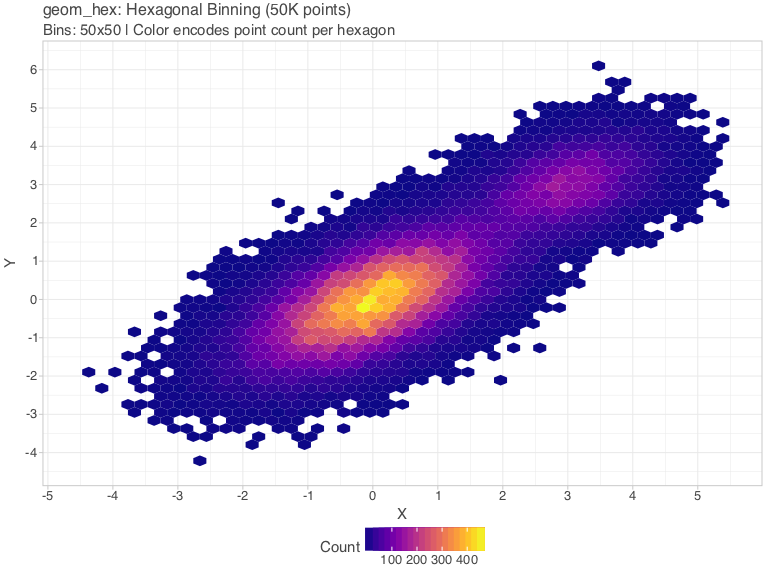

In [ ]:
p_hex = (ggplot(data, aes(x='x', y='y')) +
         geom_hex(bins=[50, 50]) +
         scale_fill_viridis(option='plasma', name='Count') +
         labs(title='geom_hex: Hexagonal Binning (50K points)',
              subtitle='Bins: 50x50 | Color encodes point count per hexagon',
              x='X', y='Y') +
         theme(legend_position='bottom'))
ggsave(p_hex, 'scatter_hex.svg', w=8, h=6, unit='in')
print('Saved scatter_hex.svg')
p_hex

## Density-Colored Points with geom_pointdensity

`geom_pointdensity()` renders **all points** but colors them by local density. This approach:
- **Shows every point** (no aggregation)
- **Colors by local density** â dense areas get distinct colors
- **Preserves individual point positions**
- **Best for**: seeing both individual points and density patterns simultaneously

Saved scatter_pointdensity.svg


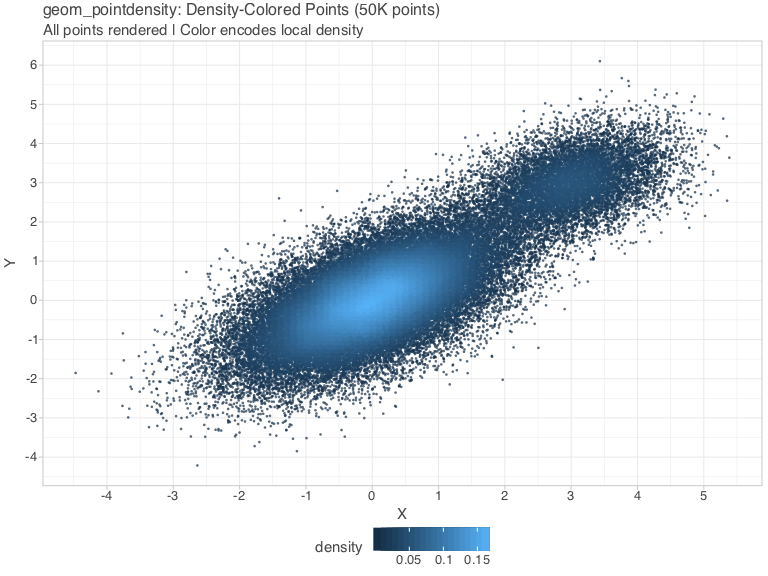

In [ ]:
p_density = (ggplot(data, aes(x='x', y='y')) +
             geom_pointdensity(method='auto', alpha=0.7, size=1.2) +
             scale_fill_viridis(option='viridis', name='Density') +
             labs(title='geom_pointdensity: Density-Colored Points (50K points)',
                  subtitle='All points rendered | Color encodes local density',
                  x='X', y='Y') +
             theme(legend_position='bottom'))
ggsave(p_density, 'scatter_pointdensity.svg', w=8, h=6, unit='in')
print('Saved scatter_pointdensity.svg')
p_density

## Side-by-Side Comparison

Using `gggrid()` to display both approaches together with shared axes for direct comparison.

Saved scatter_comparison.svg


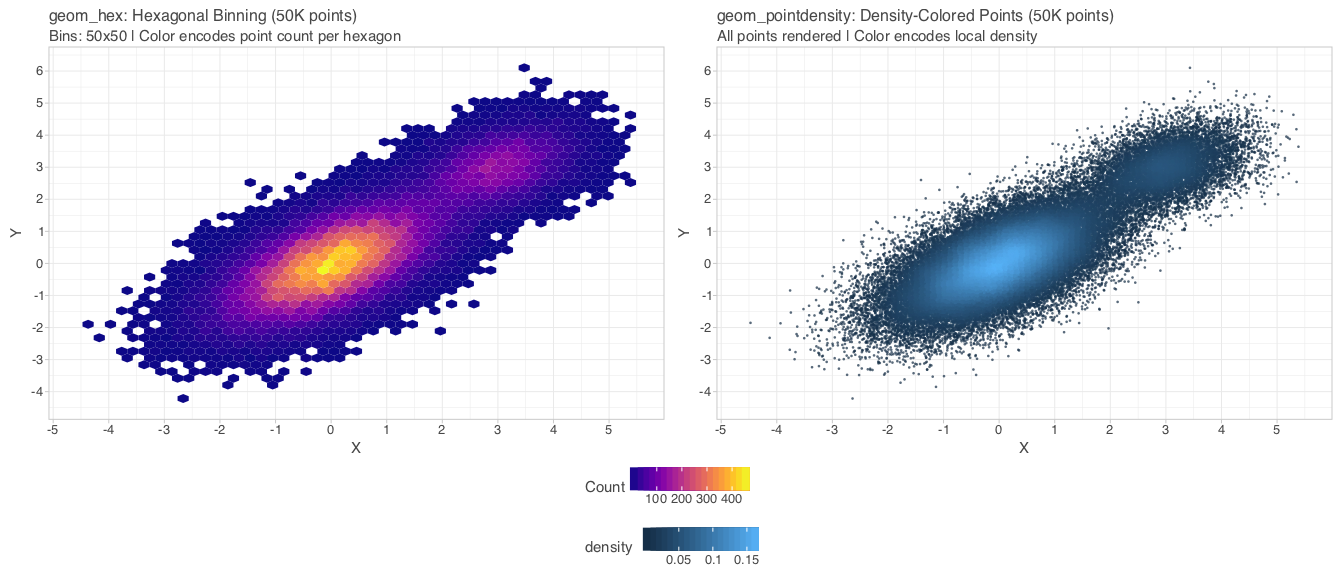

In [ ]:
grid = gggrid([p_hex, p_density], ncol=2, sharex='all', sharey='all', guides='collect')
ggsave(grid, 'scatter_comparison.svg', w=14, h=6, unit='in')
print('Saved scatter_comparison.svg')
grid

## Summary

| Feature | geom_hex | geom_pointdensity |
|---------|----------|-------------------|
| Points shown | Aggregated into bins | All points rendered |
| Density encoding | Bin count â color | Local density â color |
| Resolution control | `bins` parameter | `method` and bandwidth |
| Best for | Overall density patterns | Individual points + density |
| Performance | Fast for any size | Scales well with 50K+ points |

**Recommendation**: Use `geom_hex` when you care about aggregate density patterns and want clean, interpretable visuals. Use `geom_pointdensity` when you need to see every point while still understanding density structure.